In [297]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler

This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. The "target" field refers to the presence of heart disease in the patient. It is integer valued 0 = no disease and 1 = disease.

Attribute Information: 
1. age
2. sex. 0 - female; 1 - male
3. cp - chest pain type (4 values)
4. trestbps - resting blood pressure
5. chol - serum cholestoral in mg/dl
6. fbs - fasting blood sugar > 120 mg/dl; 0 - false; 1 - true
7. restecg - resting electrocardiographic results (values 0,1,2)
8. thalach - maximum heart rate achieved
9. exang - exercise induced angina; 0 - no; 1 - yes;
10. oldpeak = ST depression induced by exercise relative to rest
11. slope - the slope of the peak exercise ST segment
12. ca - number of major vessels (0-3) colored by flourosopy
13. thal - thalassemia test result 0 = normal; 1 = fixed defect; 2 = reversable defect
14. target - presence of heart disease. 0 → the patient does not have diagnosed heart disease 1 → the patient has heart disease


In [298]:
heart = pd.read_csv('../data/heart.csv')

In [299]:
heart.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [300]:
heart.tail(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1015,58,1,0,128,216,0,0,131,1,2.2,1,3,3,0
1016,65,1,3,138,282,1,0,174,0,1.4,1,1,2,0
1017,53,1,0,123,282,0,1,95,1,2.0,1,2,3,0
1018,41,1,0,110,172,0,0,158,0,0.0,2,0,3,0
1019,47,1,0,112,204,0,1,143,0,0.1,2,0,2,1
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [301]:
heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [302]:
heart.shape

(1025, 14)

In [303]:
heart.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [304]:
heart.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [305]:
heart.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [306]:
print(heart.duplicated().sum())

723


In [307]:
heart.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

<Axes: >

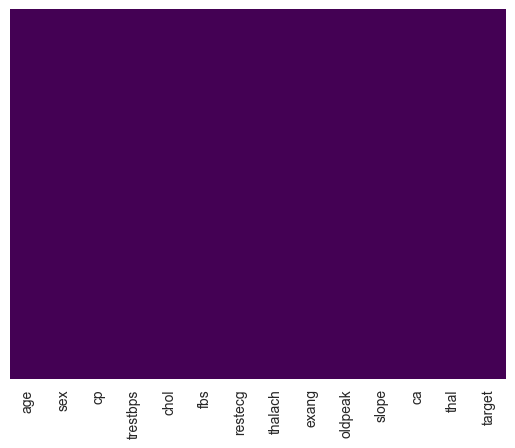

In [308]:
sns.heatmap(heart.isnull(), yticklabels=False, cbar=False, cmap='viridis')

<Axes: >

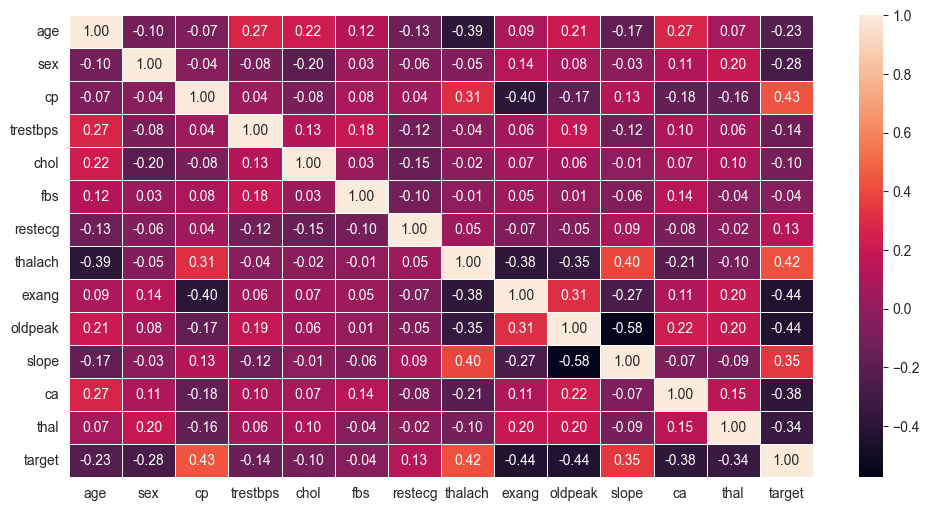

In [309]:
plt.figure(figsize=(12, 6))
sns.heatmap(heart.corr(), annot=True, fmt='.2f', linewidths=0.5)

/var/folders/r3/5pjmqzwx5kd217gbxkm_5yxm0000gn/T/ipykernel_3956/2276840228.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=heart, palette='RdBu_r')


Text(0.5, 1.0, 'Distribution of Heart Disease')

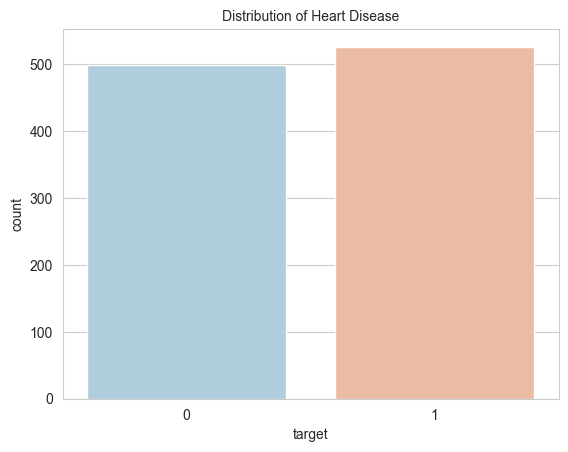

In [310]:
sns.set_style('whitegrid')
sns.countplot(x='target', data=heart, palette='RdBu_r')
plt.title("Distribution of Heart Disease", fontsize=10)

Text(0.5, 1.0, 'Distribution of Heart Disease by Sex')

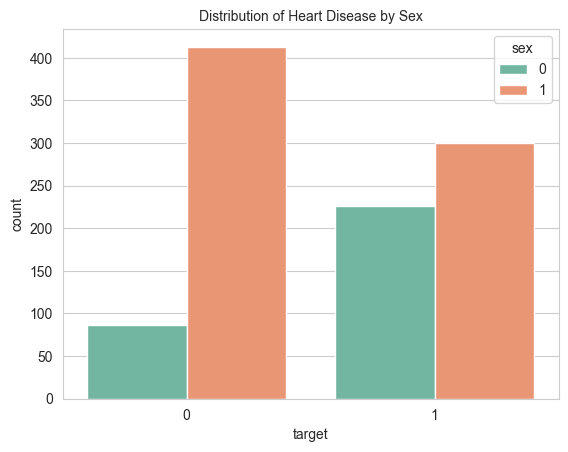

In [311]:
sns.set_style('whitegrid')
sns.countplot(x="target", hue='sex', data=heart, palette='Set2')
plt.title("Distribution of Heart Disease by Sex", fontsize=10)

Text(0.5, 1.0, 'Distribution of Heart Disease by Thalassemia Category')

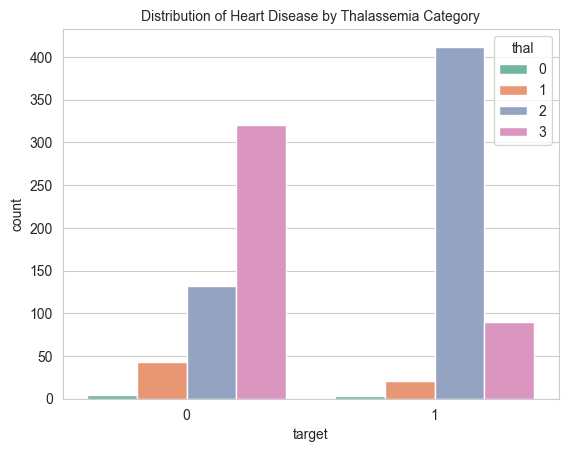

In [312]:
sns.set_style('whitegrid')
sns.countplot(x="target", hue='thal', data=heart, palette='Set2')
plt.title("Distribution of Heart Disease by Thalassemia Category", fontsize=10)

Text(0.5, 1.0, 'Chest Pain Type vs Heart Disease')

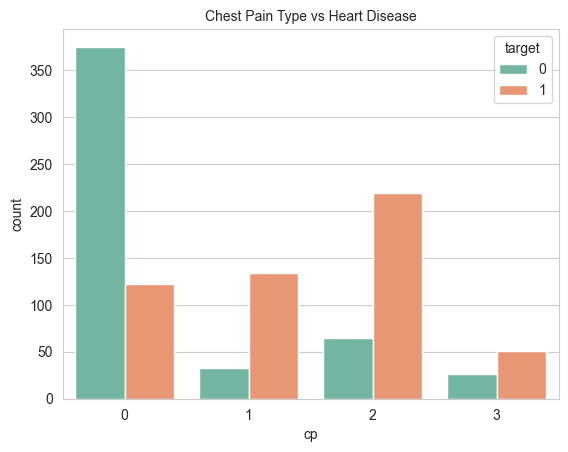

In [313]:
sns.set_style('whitegrid')
sns.countplot(x="cp", hue='target', data=heart, palette='Set2')
plt.title("Chest Pain Type vs Heart Disease", fontsize=10)

Text(0.5, 1.0, 'Exercise Induced Angina vs Heart Disease')

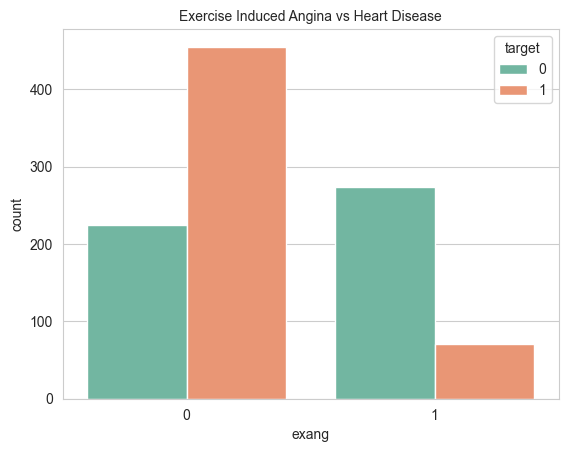

In [314]:
sns.set_style('whitegrid')
sns.countplot(x="exang", hue='target', data=heart, palette='Set2')
plt.title("Exercise Induced Angina vs Heart Disease", fontsize=10)

Text(0.5, 1.0, 'ST Depression vs Heart Disease')

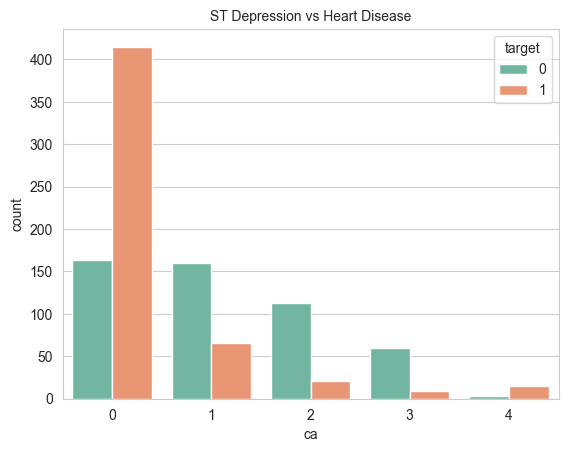

In [315]:
sns.set_style('whitegrid')
sns.countplot(x="ca", hue='target', data=heart, palette='Set2')
plt.title("ST Depression vs Heart Disease", fontsize=10)

Text(0.5, 1.0, 'Age Distribution')

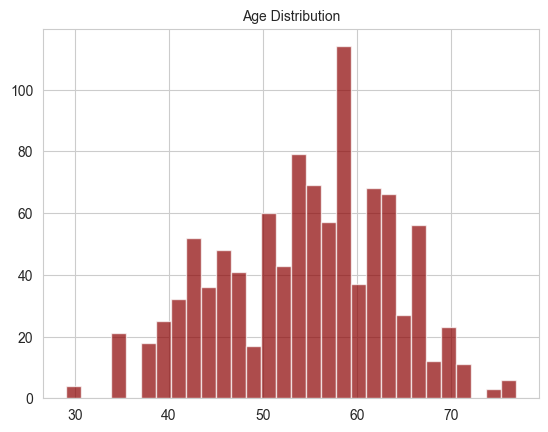

In [316]:
heart['age'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Age Distribution", fontsize=10)

Text(0.5, 1.0, 'Chest Pain Type Distribution')

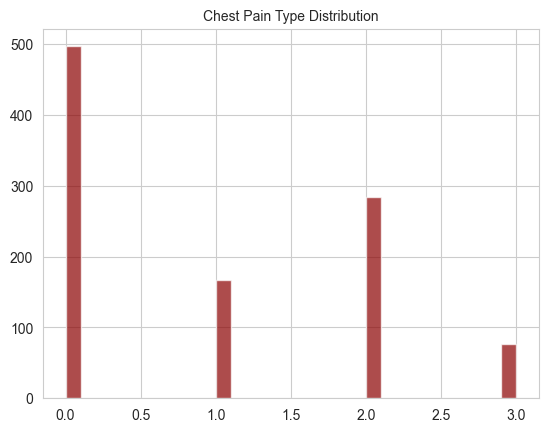

In [317]:
heart['cp'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Chest Pain Type Distribution", fontsize=10)

Text(0.5, 1.0, 'Thalassemia Distribution')

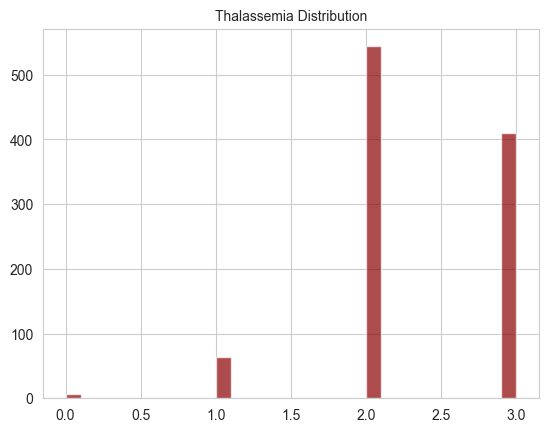

In [318]:
heart['thal'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Thalassemia Distribution", fontsize=10)

Text(0.5, 1.0, 'ST Depression vs Heart Disease')

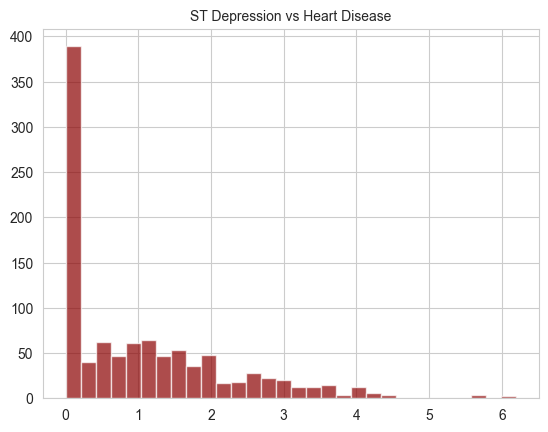

In [319]:
heart['oldpeak'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("ST Depression vs Heart Disease", fontsize=10)

Text(0.5, 1.0, 'Maximum heart rate achieved distribution')

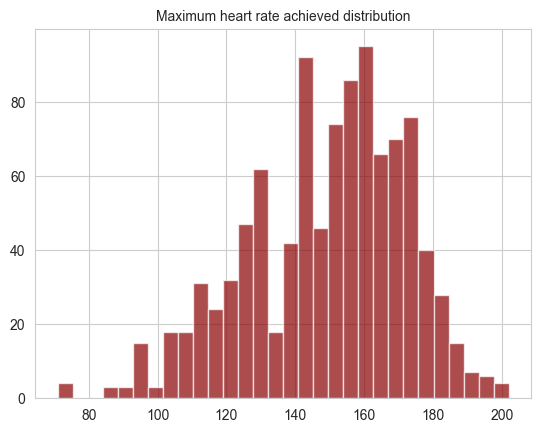

In [320]:
heart['thalach'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Maximum heart rate achieved distribution", fontsize=10)

/var/folders/r3/5pjmqzwx5kd217gbxkm_5yxm0000gn/T/ipykernel_3956/2714232606.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="age", data=heart, palette='winter')


<Axes: xlabel='target', ylabel='age'>

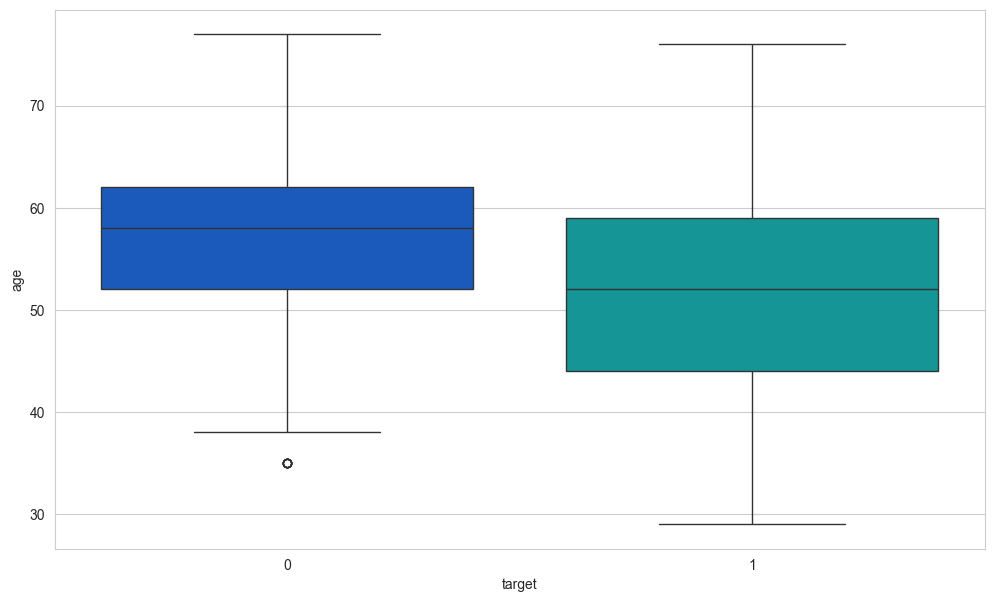

In [321]:
plt.figure(figsize=(12, 7))
sns.boxplot(x="target", y="age", data=heart, palette='winter')

In [322]:
heart.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [323]:
X_train, X_test, y_train, y_test = train_test_split(heart.drop('target',axis=1), heart['target'], test_size=0.30,random_state=101)

In [324]:
print("training test size:", X_train.shape)
print("test set size:", X_test.shape)

training test size: (717, 13)
test set size: (308, 13)


In [325]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [326]:
logmodel = LogisticRegression(max_iter=1000)

logmodel.fit(X_train,y_train)

predictions = logmodel.predict(X_test)

In [327]:
confusion_matrix(y_test, predictions)

array([[110,  38],
       [ 14, 146]])

In [328]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.89      0.74      0.81       148
           1       0.79      0.91      0.85       160

    accuracy                           0.83       308
   macro avg       0.84      0.83      0.83       308
weighted avg       0.84      0.83      0.83       308

